In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/new-plant-diseases-dataset


In [5]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import os
import glob as gb
import cv2
base_path = '/kaggle/input/new-plant-diseases-dataset/'
nested_path = os.path.join(base_path, 'New Plant Diseases Dataset(Augmented)', 'New Plant Diseases Dataset(Augmented)')

In [6]:
train = os.path.join(nested_path, 'train')

print(f"Train folder path set to: {train}")
print(f"Contents of train folder: {os.listdir(train)[:5]}")  # show first 5 classes

Train folder path set to: /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
Contents of train folder: ['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy']


In [8]:
size = 224
train_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=90,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    rescale=1./255,
    preprocessing_function=None,
    validation_split=0.1
).flow_from_directory(
    train,
    target_size=(size, size),
    batch_size=164,
    class_mode='categorical',
    color_mode='rgb',
    subset='training',
    shuffle=True
)


Found 63282 images belonging to 38 classes.


In [9]:
train_generator.class_indices

{'Apple___Apple_scab': 0,
 'Apple___Black_rot': 1,
 'Apple___Cedar_apple_rust': 2,
 'Apple___healthy': 3,
 'Blueberry___healthy': 4,
 'Cherry_(including_sour)___Powdery_mildew': 5,
 'Cherry_(including_sour)___healthy': 6,
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7,
 'Corn_(maize)___Common_rust_': 8,
 'Corn_(maize)___Northern_Leaf_Blight': 9,
 'Corn_(maize)___healthy': 10,
 'Grape___Black_rot': 11,
 'Grape___Esca_(Black_Measles)': 12,
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13,
 'Grape___healthy': 14,
 'Orange___Haunglongbing_(Citrus_greening)': 15,
 'Peach___Bacterial_spot': 16,
 'Peach___healthy': 17,
 'Pepper,_bell___Bacterial_spot': 18,
 'Pepper,_bell___healthy': 19,
 'Potato___Early_blight': 20,
 'Potato___Late_blight': 21,
 'Potato___healthy': 22,
 'Raspberry___healthy': 23,
 'Soybean___healthy': 24,
 'Squash___Powdery_mildew': 25,
 'Strawberry___Leaf_scorch': 26,
 'Strawberry___healthy': 27,
 'Tomato___Bacterial_spot': 28,
 'Tomato___Early_blight': 29,
 'Toma

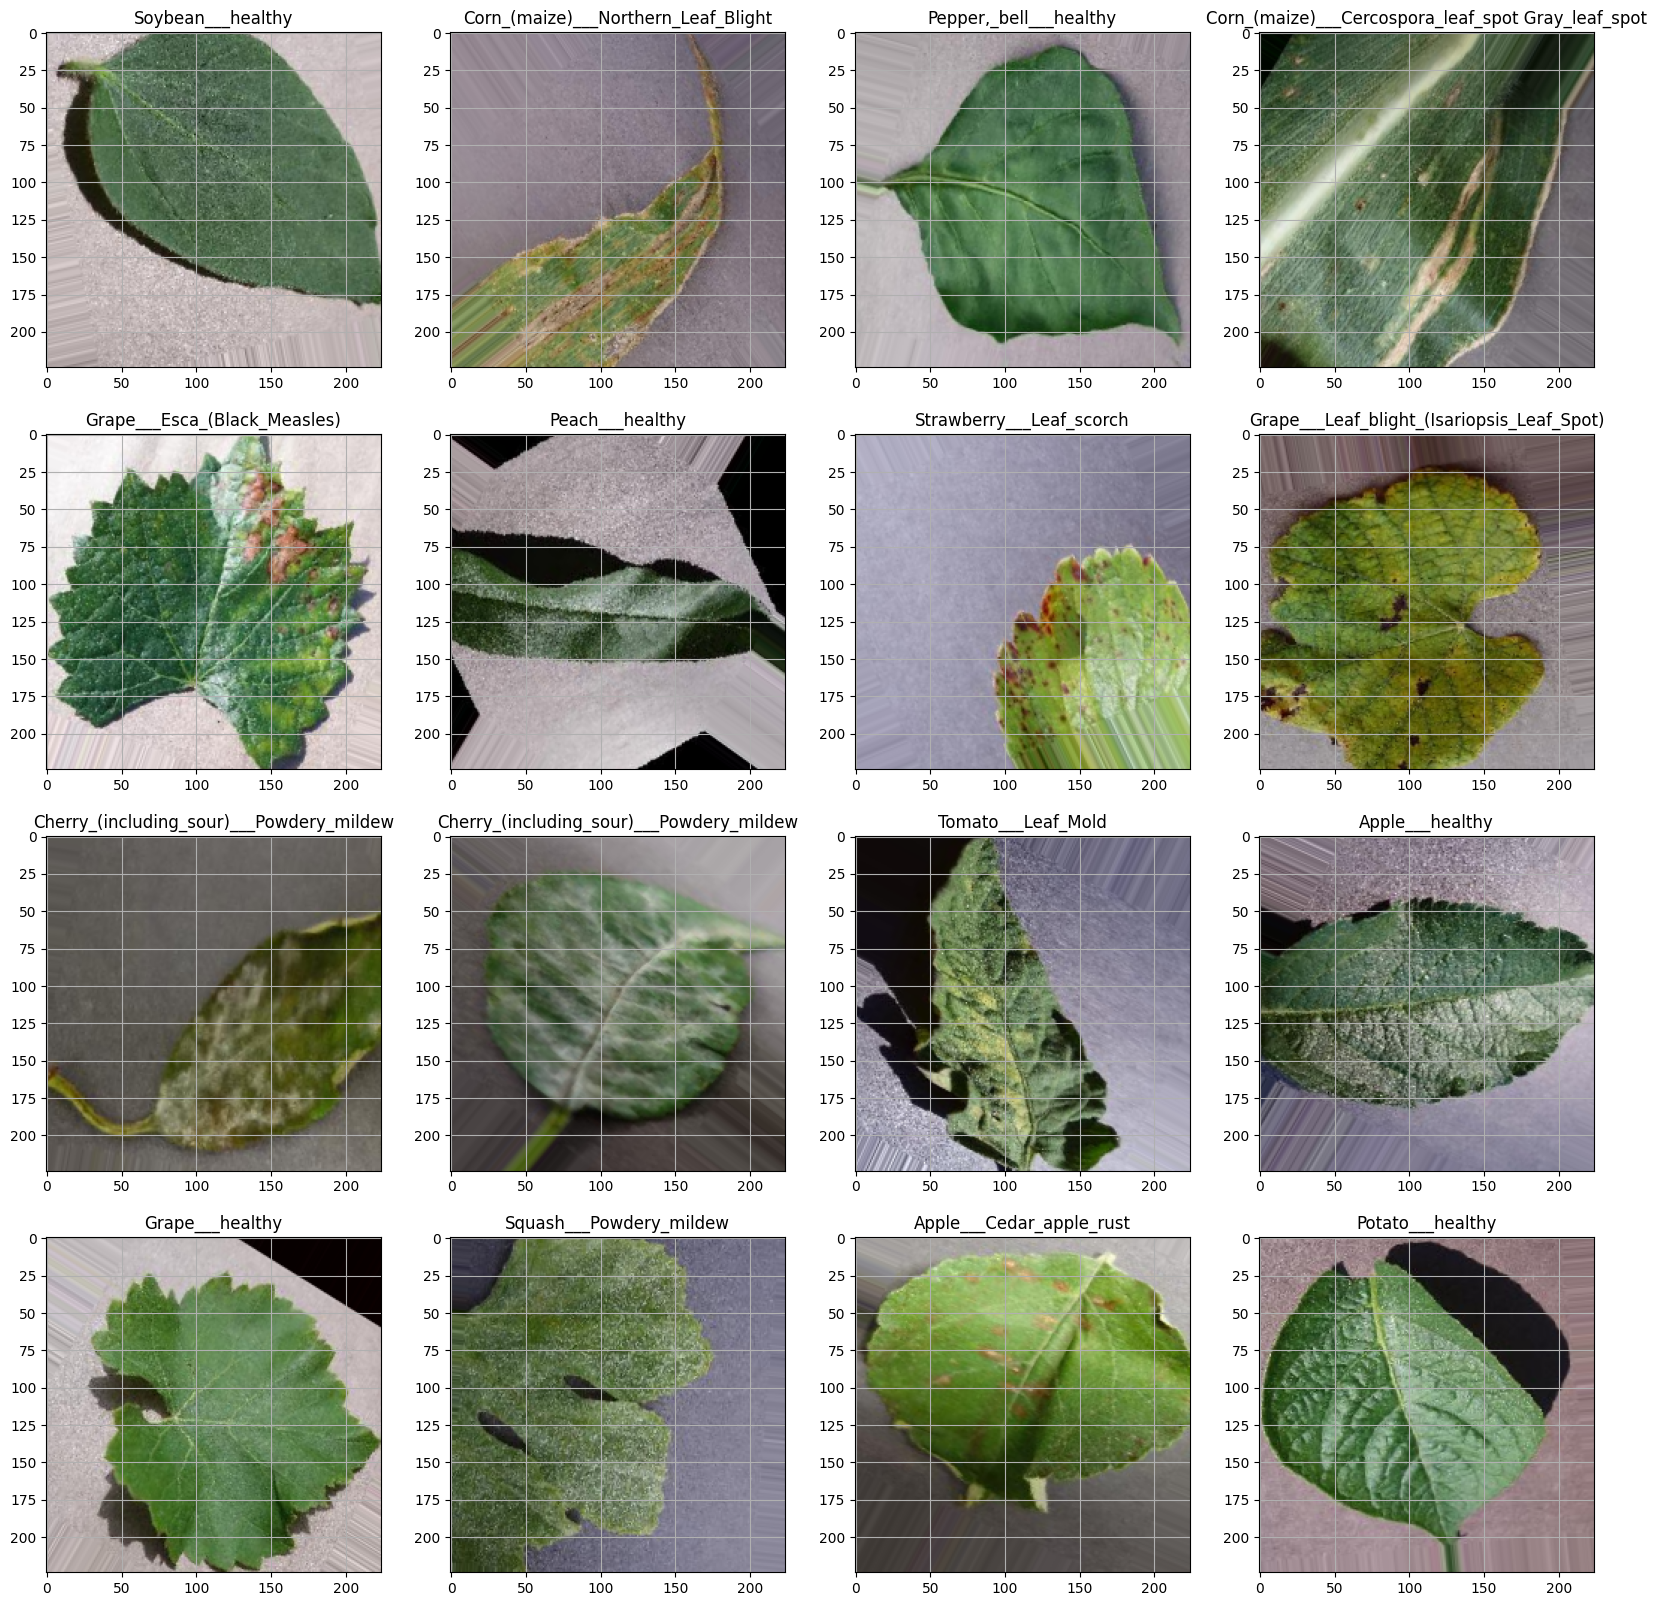

In [10]:
# Display some images
classes = list(train_generator.class_indices.keys())
plt.figure(figsize=(20,20))
for X_batch, y_batch in train_generator:
  for i in range(0, 16):
    plt.subplot(4, 4, i+1)
    plt.imshow(X_batch[i])
    plt.title(classes[np.where(y_batch[i]==1)[0][0]])
    plt.grid(None)
  plt.show()
  break

In [11]:
valid=os.path.join(nested_path, 'valid')

In [12]:
valid_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1/255.0,
    preprocessing_function = None,
).flow_from_directory(valid,
                      batch_size=164,
                      target_size=(size, size),
                      class_mode='categorical',
                      color_mode='rgb',
                      shuffle=False)

Found 17572 images belonging to 38 classes.


In [13]:
test = '/kaggle/input/new-plant-diseases-dataset/test'
test_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1/255.0
).flow_from_directory(
    directory='/kaggle/input/new-plant-diseases-dataset/',
    classes=['test'],  # Only look inside the 'test' folder
    target_size=(224, 224),
    batch_size=1,
    color_mode='rgb',
    class_mode=None,   # Because there are no labels
    shuffle=False      # So predictions match file order
)


Found 33 images belonging to 1 classes.


In [14]:
test_generator.class_indices

{'test': 0}

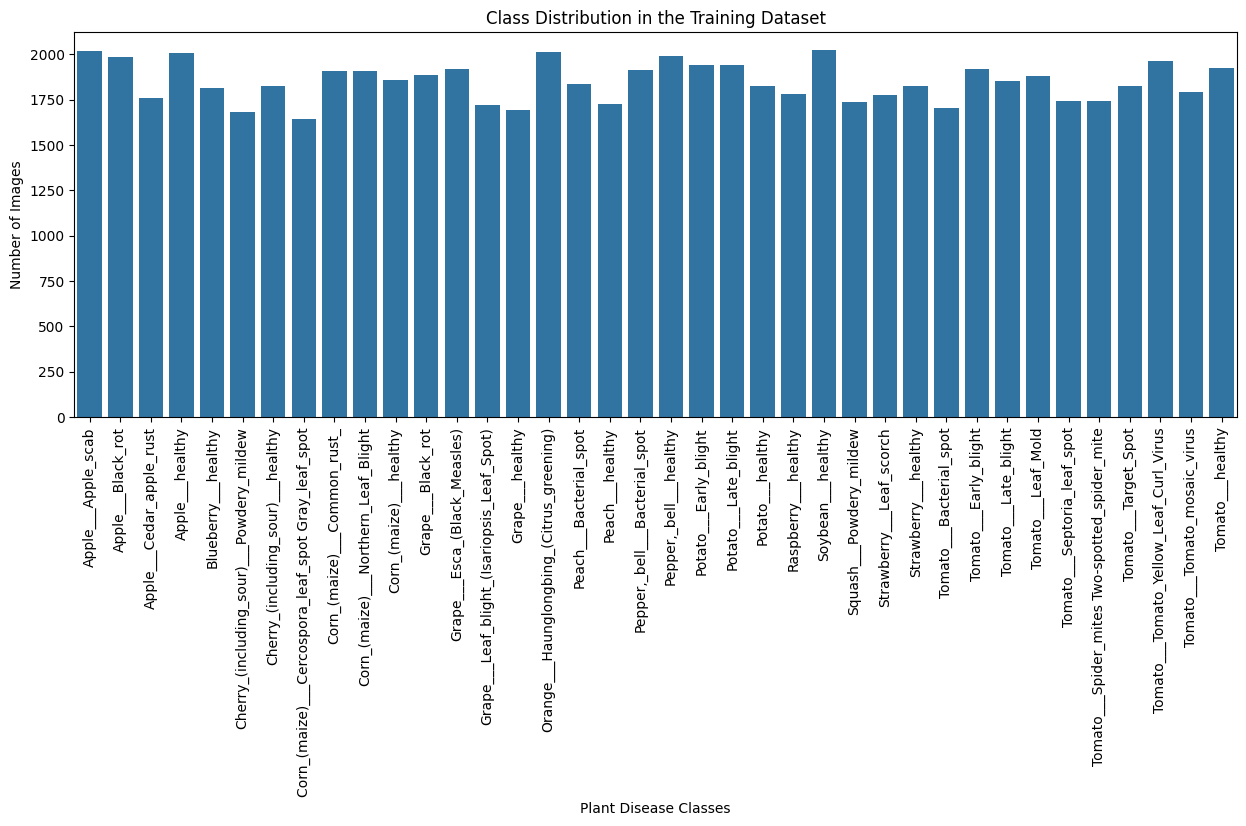

In [15]:
import seaborn as sns

class_counts = {k: len(os.listdir(os.path.join(train, k))) for k in train_generator.class_indices.keys()}
plt.figure(figsize=(15,5))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.xticks(rotation=90)
plt.xlabel("Plant Disease Classes")
plt.ylabel("Number of Images")
plt.title("Class Distribution in the Training Dataset")
plt.show()


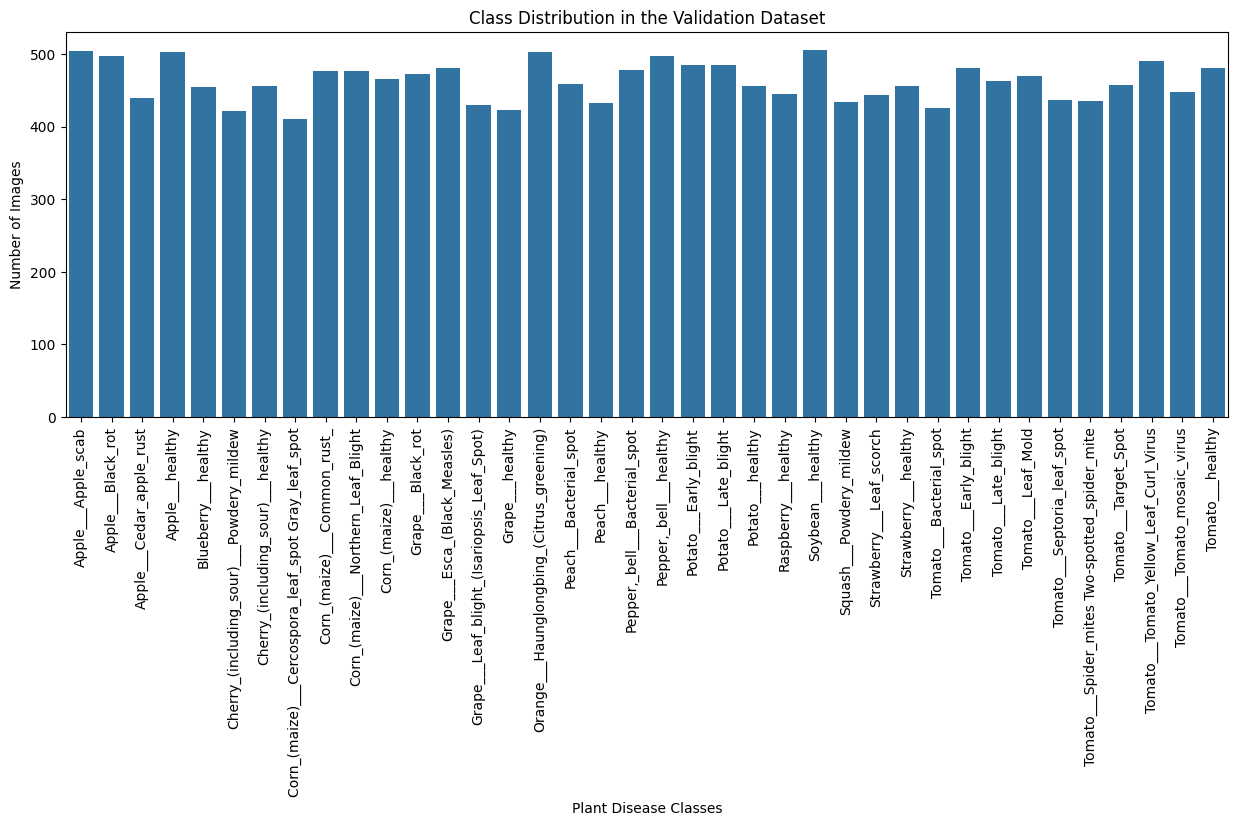

In [16]:
valid_class_counts = {k: len(os.listdir(os.path.join(valid, k))) for k in train_generator.class_indices.keys()}

# Plotting
plt.figure(figsize=(15,5))
sns.barplot(x=list(valid_class_counts.keys()), y=list(valid_class_counts.values()))
plt.xticks(rotation=90)
plt.xlabel("Plant Disease Classes")
plt.ylabel("Number of Images")
plt.title("Class Distribution in the Validation Dataset")
plt.show()

In [17]:
from tensorflow import keras

model = keras.models.Sequential()

model.add(keras.layers.Conv2D(filters=32, kernel_size=7, strides=1, padding='same',
                              activation='relu', name="Conv1", input_shape=(224, 224, 3)))
model.add(keras.layers.MaxPool2D(pool_size=2, name="Pool1"))

model.add(keras.layers.Conv2D(filters=64, kernel_size=5, strides=1, padding='same',
                              activation='relu', name='Conv2'))
model.add(keras.layers.MaxPool2D(pool_size=2, name="Pool2"))

model.add(keras.layers.Conv2D(filters=128, kernel_size=3, strides=1, padding='same',
                              activation='relu', name='Conv3'))
model.add(keras.layers.MaxPool2D(pool_size=2, name="Pool3"))

model.add(keras.layers.Conv2D(filters=256, kernel_size=3, strides=1, padding='same',
                              activation='relu', name='Conv4'))
model.add(keras.layers.MaxPool2D(pool_size=2, name="Pool4"))  # Important!

model.add(keras.layers.Flatten(name='Flatten1'))

model.add(keras.layers.Dense(128, activation='relu', name='Dense1'))
model.add(keras.layers.Dropout(0.5))  # Correctly added dropout

model.add(keras.layers.Dense(64, activation='relu', name='Dense2'))
model.add(keras.layers.Dropout(0.5))  # Correctly added dropout

model.add(keras.layers.Dense(38, activation='softmax', name='Output'))

print(model.summary())


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1 (Conv2D)                  │ (None, 224, 224, 32)   │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool1 (MaxPooling2D)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 112, 112, 64)   │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool2 (MaxPooling2D)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3 (Conv2D)                  │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool3 (MaxPooling2D)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv4 (Conv2D)                  │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool4 (MaxPooling2D)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten1 (Flatten)              │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense1 (Dense)                  │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense2 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 38)             │         2,470 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,858,406 (26.16 MB)

 Trainable params: 6,858,406 (26.16 MB)

 Non-trainable params: 0 (0.00 B)

None


In [19]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    'best_modelV1CNN.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

model_reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

callbacks = [early_stopping, model_checkpoint, model_reduce_lr]


In [20]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)


In [21]:
history = model.fit(train_generator, epochs=5, validation_data=valid_generator, callbacks=callbacks)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
386/386 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.0534 - auc: 0.5712 - loss: 3.5649 - precision: 0.6377 - recall: 0.0089
Epoch 1: val_loss improved from inf to 3.16272, saving model to best_modelV1CNN.keras
386/386 ━━━━━━━━━━━━━━━━━━━━ 1239s 3s/step - accuracy: 0.0535 - auc: 0.5714 - loss: 3.5646 - precision: 0.6380 - recall: 0.0089 - val_accuracy: 0.1533 - val_auc: 0.7709 - val_loss: 3.1627 - val_precision: 0.9231 - val_recall: 0.0212 - learning_rate: 0.0010
Epoch 2/5
386/386 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1573 - auc: 0.8077 - loss: 2.9638 - precision: 0.6905 - recall: 0.0302
Epoch 2: val_loss improved from 3.16272 to 2.17949, saving model to best_modelV1CNN.keras
386/386 ━━━━━━━━━━━━━━━━━━━━ 910s 2s/step - accuracy: 0.1574 - auc: 0.8078 - loss: 2.9633 - precision: 0.6904 - recall: 0.0302 - val_accuracy: 0.3580 - val_auc: 0.9218 - val_loss: 2.1795 - val_precision: 0.8984 - val_recall: 0.0770 - learning_rate: 0.0010
Epoch 3/5
386/386 ━━━━━━━━━━━━━━━━━━━━ 0s

In [ ]:
# Load your saved best model
model = keras.models.load_model('best_modelV1CNN.keras')

# Then continue training from that checkpoint
history = model.fit(
    train_generator,
    epochs=20,  # total epochs you wanna train from here
    validation_data=valid_generator,
    callbacks=callbacks
)


Epoch 1/20
386/386 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5838 - auc: 0.9661 - loss: 1.3647 - precision: 0.7901 - recall: 0.4081
Epoch 1: val_loss improved from 0.92239 to 0.76543, saving model to best_modelV1CNN.keras
386/386 ━━━━━━━━━━━━━━━━━━━━ 916s 2s/step - accuracy: 0.5839 - auc: 0.9661 - loss: 1.3646 - precision: 0.7901 - recall: 0.4082 - val_accuracy: 0.7688 - val_auc: 0.9901 - val_loss: 0.7654 - val_precision: 0.8841 - val_recall: 0.6266 - learning_rate: 0.0010
Epoch 2/20
386/386 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6400 - auc: 0.9734 - loss: 1.1808 - precision: 0.8055 - recall: 0.4827
Epoch 2: val_loss improved from 0.76543 to 0.64175, saving model to best_modelV1CNN.keras
386/386 ━━━━━━━━━━━━━━━━━━━━ 886s 2s/step - accuracy: 0.6400 - auc: 0.9734 - loss: 1.1807 - precision: 0.8055 - recall: 0.4827 - val_accuracy: 0.8109 - val_auc: 0.9925 - val_loss: 0.6418 - val_precision: 0.9038 - val_recall: 0.6990 - learning_rate: 0.0010
Epoch 3/20
386/386 ━━━━━━━━━━━━━━━━━

In [ ]:
import seaborn as sns

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

precision = history.history['precision']
val_precision = history.history['val_precision']

recall = history.history['recall']
val_recall = history.history['val_recall']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

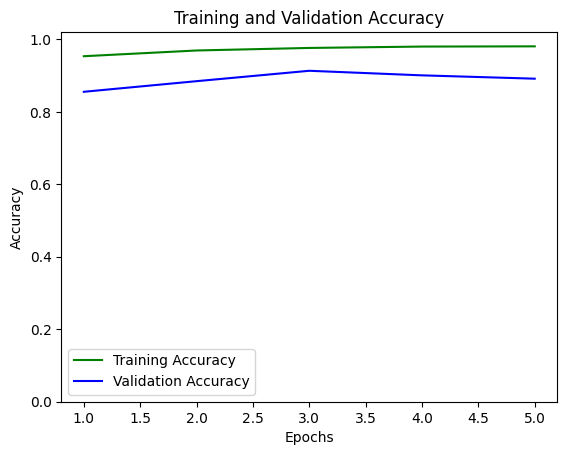

In [ ]:
plt.plot(epochs, acc, color='green', label='Training Accuracy')
plt.plot(epochs, val_acc, color='blue', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.ylim(0, 1.02)
plt.show()

In [ ]:
model_evaluate = model.evaluate(test_generator)
print("loss:", model_evaluate[0])
print("accuracy:", model_evaluate[1])
print("precision:", model_evaluate[2])
print("recall:", model_evaluate[3])

108/108 ━━━━━━━━━━━━━━━━━━━━ 39s 359ms/step - accuracy: 0.9202 - loss: 0.3161 - precision: 0.9263 - recall: 0.9174
loss: 0.35824888944625854
accuracy: 0.9064989686012268
precision: 0.9139679670333862
recall: 0.9026291966438293


In [ ]:
# save the model
model.save('cnn_model.keras')